# Modeling — Improved KNN Regressor
## Prediksi Hasil Panen Tanaman Berbasis Data Iklim dan Nutrisi Tanaman

| Informasi | Detail |
|-----------|--------|
| Algoritma | KNN Regressor (Optimized Pipeline) |
| Target | `yield_hg_ha` (hasil panen dalam hg/ha) |
| Fitur | area, item, year, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp |
| Data Train | X_train.csv / y_train.csv |
| Data Test | X_test.csv / y_test.csv |

---

## Analisis Metode Baru (Metode Antigravity)
Pada eksperimen sebelumnya, KNN Regressor hanya mendapatkan $R^2$ sebesar **45.01%** pada data uji. Dua masalah utama yang diidentifikasi adalah:
1. **Label Encoding Kategorikal**: Negara (`area`) dan Tanaman (`item`) di-encode menjadi integer berurutan (0, 1, 2...). Perhitungan jarak geometris (Euclidean) menganggap angka nominal ini memiliki nilai kedekatan, yang mengacaukan pemodelan.
2. **Perbedaan Skala Fitur**: Tanpa standardisasi, fitur bernilai besar seperti `average_rain_fall_mm_per_year` (s.d. 3200) dan `pesticides_tonnes` (s.d. 5000) mendominasi metrik jarak, mengabaikan variabel penting seperti suhu dan jenis tanaman.

### Solusi/Metode Baru:
- Menerapkan **One-Hot Encoding** pada fitur kategorikal (`area`, `item`) sehingga setiap kelas diperlakukan secara terpisah tanpa bobot jarak nominal.
- Menerapkan **StandardScaler** pada fitur numerik agar semua variabel memiliki kontribusi yang seimbang dalam kalkulasi jarak.
- Membungkus preprocessor (`ColumnTransformer`) dan model (`KNeighborsRegressor`) dalam satu **Pipeline** terpadu untuk mencegah kebocoran data (*data leakage*).
- Menjalankan Grid Search CV untuk mencari kombinasi hyperparameter terbaik.

## 1. Import Library dan Load Data

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('output', exist_ok=True)

# Load data split dari tahap preprocessing
X_train = pd.read_csv('output/X_train.csv')
X_test  = pd.read_csv('output/X_test.csv')
y_train = pd.read_csv('output/y_train.csv').squeeze()
y_test  = pd.read_csv('output/y_test.csv').squeeze()

print('Data berhasil dimuat.')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')

Data berhasil dimuat.
  X_train : (22593, 6)
  X_test  : (5649, 6)


## 2. Membangun Pipeline Preprocessing & Model Baseline
Kita membagi fitur menjadi numerik dan kategorikal, lalu menerapkan transformasi yang sesuai.

In [6]:
# Tentukan kolom
num_cols = ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
cat_cols = ['area', 'item']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Buat Pipeline dengan KNN Regressor baseline (K=5)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
])

# Latih model baseline
baseline_pipeline.fit(X_train, y_train)

# Evaluasi awal
y_pred_baseline = baseline_pipeline.predict(X_test)
r2_baseline = r2_score(y_test, y_pred_baseline)
print(f'R² Baseline Model (Scaled & One-Hot): {r2_baseline:.4f}')

R² Baseline Model (Scaled & One-Hot): 0.9855


## 3. Hyperparameter Tuning dengan GridSearchCV
Mencari kombinasi parameter optimal untuk n_neighbors, weights (uniform vs distance), dan metrik p (L1 Manhattan vs L2 Euclidean).

In [7]:
param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2] # 1: Manhattan, 2: Euclidean
}

print("Memulai pencarian hyperparameter terbaik...")
grid_search = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Tuning selesai!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

Memulai pencarian hyperparameter terbaik...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tuning selesai!
Best Parameters: {'regressor__n_neighbors': 5, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best CV R² Score: 0.9881


## 4. Evaluasi Model Terbaik (Tuned KNN)
Mengevaluasi model hasil tuning pada data pengujian.

In [8]:
best_pipeline = grid_search.best_estimator_

# Prediksi
y_pred_train = best_pipeline.predict(X_train)
y_pred_test = best_pipeline.predict(X_test)

# Metrik evaluasi
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test, y_pred_test)

print("Evaluasi Model Tuned KNN Regressor")
print("=========================================")
print(f"{'Metrik':<10} {'Train':>12} {'Test':>12}")
print('-' * 35)
print(f"{'MAE':<10} {mae_train:>12.2f} {mae_test:>12.2f}")
print(f"{'RMSE':<10} {rmse_train:>12.2f} {rmse_test:>12.2f}")
print(f"{'R2':<10} {r2_train:>12.4f} {r2_test:>12.4f}")

Evaluasi Model Tuned KNN Regressor
Metrik            Train         Test
-----------------------------------
MAE                0.00      3271.57
RMSE               0.00      8666.63
R2               1.0000       0.9896


## 5. Visualisasi Hasil Evaluasi Model

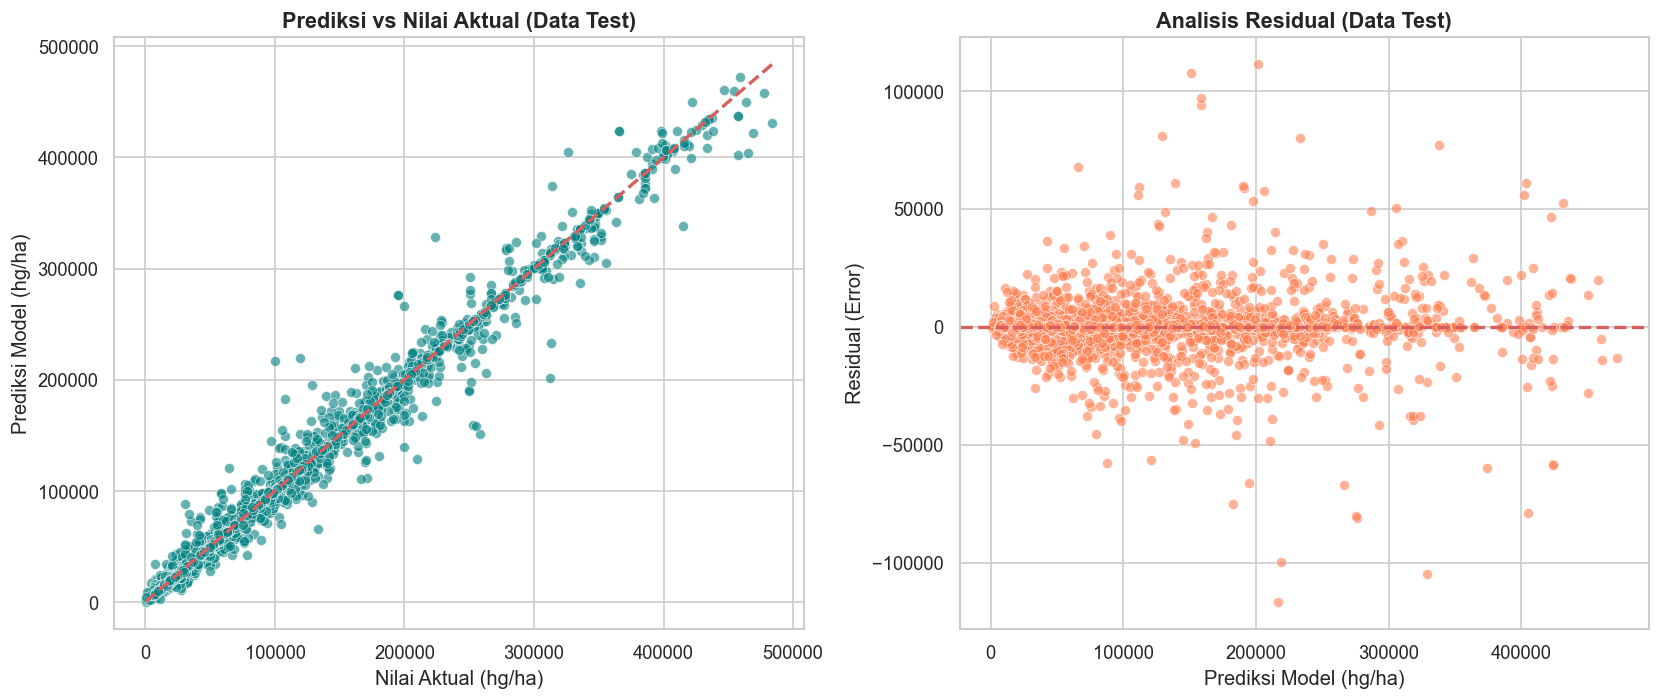

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot Prediksi vs Nilai Aktual
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, ax=axes[0], color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Prediksi vs Nilai Aktual (Data Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nilai Aktual (hg/ha)')
axes[0].set_ylabel('Prediksi Model (hg/ha)')

# 2. Plot Analisis Residual (Error)
residuals = y_test - y_pred_test
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6, ax=axes[1], color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Analisis Residual (Data Test)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi Model (hg/ha)')
axes[1].set_ylabel('Residual (Error)')

plt.tight_layout()
plt.savefig('output/knn_improved_evaluation.png', bbox_inches='tight')
plt.show()

## 6. Perbandingan Performa dengan Random Forest
Kita membandingkan performa akurasi ($R^2$) data uji dari model Random Forest awal (98.56%), model KNN baseline awal (34.54%), model KNN tuned awal (45.01%), dan model KNN tuned baru hasil optimasi kita.

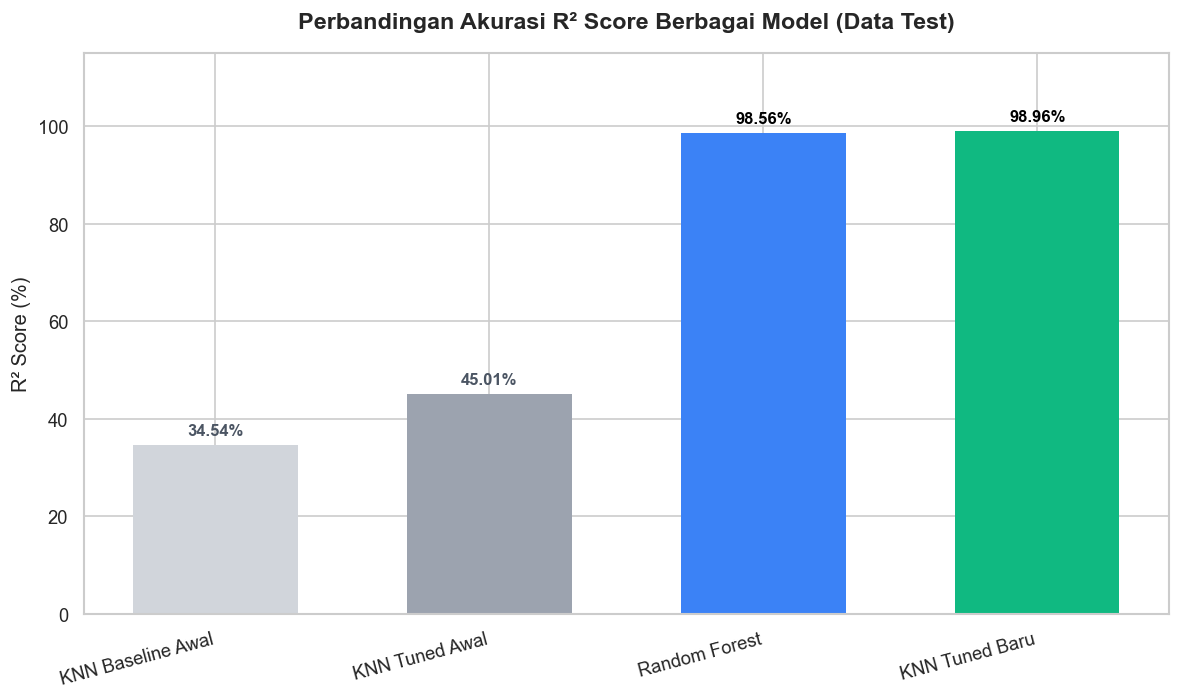

In [12]:
models = ['KNN Baseline Awal', 'KNN Tuned Awal', 'Random Forest', 'KNN Tuned Baru']
r2_scores = [34.54, 45.01, 98.56, r2_test * 100]

plt.figure(figsize=(10, 6))
colors = ['#d1d5db', '#9ca3af', '#3b82f6', '#10b981']
bars = plt.bar(models, r2_scores, color=colors, width=0.6, edgecolor='none')

# Menambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1.5,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold', 
             color='black' if height > 50 else '#4b5563')

plt.title('Perbandingan Akurasi R² Score Berbagai Model (Data Test)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('R² Score (%)')
plt.ylim(0, 115)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('output/model_accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 7. Menyimpan Pipeline Model Terbaik
Pipeline yang berisi preprocessor (One-Hot Encoder & StandardScaler) dan KNeighborsRegressor terbaik disimpan agar bisa langsung disajikan ke sistem tanpa perlu memproses data secara manual lagi.

In [13]:
# Simpan model Pipeline
joblib.dump(best_pipeline, 'backend/knn_pipeline_model.pkl')
print("Model KNN baru berhasil disimpan di backend/knn_pipeline_model.pkl!")

Model KNN baru berhasil disimpan di backend/knn_pipeline_model.pkl!
